## 1. Load Artifacts

In [21]:
import torch
import numpy as np
import random


In [22]:
import json
import pandas as pd

with open("artifacts/class_mapping.json", "r") as f:
    class_to_idx = json.load(f)

class_to_idx = {k: int(v) for k, v in class_to_idx.items()}
idx_to_class = {v: k for k, v in class_to_idx.items()}

df = pd.read_csv("artifacts/data_split.csv")

train_df = df[df["split"] == "train"]
test_df = df[df["split"] == "test"]

train_paths = train_df["image_path"].tolist()
train_labels = train_df["label"].tolist()

test_paths = test_df["image_path"].tolist()
test_labels = test_df["label"].tolist()

NUM_CLASSES = len(class_to_idx)

## 2. Dataset + Dataloader

In [23]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGE_SIZE = 224
BATCH_SIZE = 32

# ImageNet normalization (IMPORTANT)
train_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class XrayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Invalid image: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

        if self.transform:
            image = self.transform(image=image)["image"]

        label = self.labels[idx]
        return image, label

train_dataset = XrayDataset(train_paths, train_labels, train_transforms)
val_dataset = XrayDataset(test_paths, test_labels, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 3. Load Pretrained ResNet50

In [24]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet50(pretrained=True)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 4. Training Setup

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

## 5. Train (Phase 1: Frozen Backbone)

In [26]:
EPOCHS = 10
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"[Frozen] Epoch {epoch+1}, Loss: {total_loss:.4f}")

[Frozen] Epoch 1, Loss: 8.4295
[Frozen] Epoch 2, Loss: 6.2392
[Frozen] Epoch 3, Loss: 5.1564
[Frozen] Epoch 4, Loss: 4.0922
[Frozen] Epoch 5, Loss: 3.6526
[Frozen] Epoch 6, Loss: 3.3781
[Frozen] Epoch 7, Loss: 2.9508
[Frozen] Epoch 8, Loss: 2.9582
[Frozen] Epoch 9, Loss: 2.7805
[Frozen] Epoch 10, Loss: 2.6072


## 7. Evaluation

In [27]:
from sklearn.metrics import classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=idx_to_class.values()))

                 precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       1.00      0.50      0.67        20
Viral Pneumonia       0.67      1.00      0.80        20

       accuracy                           0.85        66
      macro avg       0.89      0.83      0.82        66
   weighted avg       0.90      0.85      0.84        66



## 8. Confusion Matrix

In [28]:
import torch
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[26  0  0]
 [ 0 10 10]
 [ 0  0 20]]


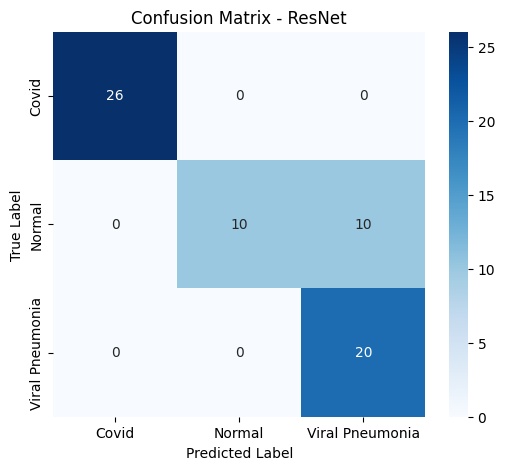

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=idx_to_class.values(),
    yticklabels=idx_to_class.values()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet")

plt.show()

## 9. Save Model

In [30]:
torch.save(model.state_dict(), "artifacts/resnet_model.pth")